In [27]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [26]:
from fastai.torch_basics import tensor, to_np

In [16]:
# Declare loss function
def f(x): return x**2
# We want to calculate gradients w.r.t. that variable at that value (tagging variable)
xt = tensor(3.).requires_grad_()
# Calculate function with value
yt = f(xt)
# Calculate backpropagation
yt.backward()
# Get the gradient
print(f"Gradient: {xt.grad}")

Gradient: 6.0


In [17]:
# Declare loss function with sum
def f(x): return (x**2).sum()
# We want to calculate gradients w.r.t. that variable at that values (tagging variable)
xt = tensor([3., 4., 10.]).requires_grad_()
# Calculate function with value
yt = f(xt)
# Calculate backpropagation
yt.backward()
# Get the gradient
print(f"Gradient: {xt.grad}")

Gradient: tensor([ 6.,  8., 20.])


31774.525390625
6552.8466796875
1780.1217041015625
876.96142578125
706.0413818359375
673.6835327148438
667.5460205078125
666.3699951171875
666.1329345703125
666.0736083984375


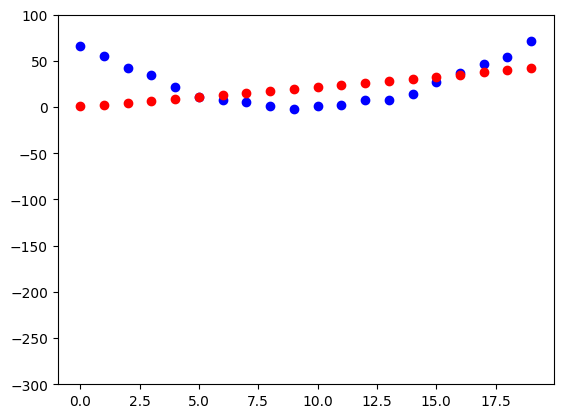

In [57]:
# Assign values to independent variable
x = torch.arange(0, 20).float()

# Out targets
y = torch.randn(20) * 3 + 0.75 * (x - 9.5) ** 2 + 1
# Assign random values to params
params = torch.randn(3, requires_grad=True)

# Declare a model (quadratic function)
def f(t, params):
    a,b,c = params
    return a*(t**2) + (b*t) + c

# Show prediction routine
def show_preds(preds, ax=None):
    if ax is None: ax=plt.subplots()[1]
    ax.scatter(x, y, color="blue")
    ax.scatter(x, to_np(preds), color="red")
    ax.set_ylim(-300,100)

# Apply step routine
def apply_step(params, lr=1e-5, prn=True):
    y_hat = f(x, params)
    loss = F.mse_loss(y_hat, y)
    loss.backward()
    params.data -= lr * params.grad.data
    params.grad = None
    if prn: print(loss.item())
    return y_hat

# Apply steps to adjust model params
for i in range(10): apply_step(params)
# Display predictions
show_preds(preds=f(x, params))